# Pipeline Model Prediksi Kesehatan Mental

Notebook ini merangkum proses dari awal hingga akhir untuk konversi data, preprocessing, analisa kolom, hingga pelatihan model SVM.

## 0. Instalasi Dependensi

Jalankan sel di bawah ini untuk menginstal library yang dibutuhkan sebelum memulai pipeline.

In [1]:
!pip install pandas numpy scikit-learn numbers-parser joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 7.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 20.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.0 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.0 which is incompatible.
google-cloud-discoveryengine 0.13.12 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.0 which is incompatible.
googl

## 1. Konversi Format `.numbers` ke CSV

Menggunakan library `numbers_parser` untuk mengekstrak tabel dari data spreadsheet Numbers.

In [ ]:
from numbers_parser import Document
import csv
import sys

try:
    doc = Document("data skripsi.numbers")
    sheets = doc.sheets
    if not sheets:
        print("No sheets found.")
        sys.exit(1)
        
    tables = sheets[0].tables
    if not tables:
        print("No tables found in the first sheet.")
        sys.exit(1)
        
    data = tables[0].rows(values_only=True)
    
    with open("data skripsi.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        for row in data:
            writer.writerow(row)
            
    print("Success: data skripsi.csv created")
except Exception as e:
    print(f"Error: {e}")
    sys.exit(1)


## 2. Pra-pemrosesan Data & Skoring DASS-21

Mengkategorikan skor depresi, kecemasan, dan stres, lalu memberikan rekomendasi berdasarkan hasil skoring.

In [2]:
import pandas as pd
import numpy as np

# Fungsi pelabelan berdasarkan kriteria DASS-21 (Format 0-4 Numerik dari Klien)
def categorize_depression(score):
    if score <= 9: return 0    # Normal
    elif score <= 13: return 1 # Ringan (Mild)
    elif score <= 20: return 2 # Sedang (Moderate)
    elif score <= 27: return 3 # Parah (Severe)
    else: return 4             # Sangat Parah (Extremely Severe)

def categorize_anxiety(score):
    if score <= 7: return 0
    elif score <= 9: return 1
    elif score <= 14: return 2
    elif score <= 19: return 3
    else: return 4

def categorize_stress(score):
    if score <= 14: return 0
    elif score <= 18: return 1
    elif score <= 25: return 2
    elif score <= 33: return 3
    else: return 4

def get_recommendation(dep_cat, anx_cat, str_cat):
    severities = [dep_cat, anx_cat, str_cat]
    if 4 in severities or 3 in severities:
        return "Sangat disarankan untuk segera berkonsultasi dengan psikolog atau psikiater terdekat untuk penanganan lebih lanjut."
    elif 2 in severities:
        return "Disarankan untuk melakukan konseling, membatasi screen-time berlebih, dan relaksasi pikiran."
    elif 1 in severities:
        return "Pertahankan pola hidup sehat, atur waktu penggunaan gadget, dan perbanyak interaksi sosial di dunia nyata."
    else:
        return "Kondisi mental terpantau stabil dan sehat. Terus pertahankan aktivitas positif dan pola hidup seimbang!"

try:
    print("Memuat data skripsi...")
    df = pd.read_csv("data_skripsi1.csv")
    
    # Mencari kolom-kolom DASS-21
    dass_cols = [col for col in df.columns if "DASS-21" in col]
    
    # Cek konsistensi jumlah pertanyaan DASS (Harusnya 21)
    if len(dass_cols) != 21:
        print(f"Peringatan: Jumlah kolom DASS-21 yang ditemukan adalah {len(dass_cols)} (Seharusnya 21)")
        
    print(f"Berhasil menemukan {len(dass_cols)} kolom kuesioner psikologis.")
    
    # Standar DASS-21 Sub-skala (1-based index) -> di mana indeks pada Dass_cols adalah 0-based
    # Depression: 3, 5, 10, 13, 16, 17, 21
    # Anxiety:    2, 4,  7,  9, 15, 19, 20
    # Stress:     1, 6,  8, 11, 12, 14, 18
    
    # Mapping indeks kolom (0-based) berdasarkan urutan pertanyaan di kuesioner
    dep_indices = [2, 4, 9, 12, 15, 16, 20]
    anx_indices = [1, 3, 6, 8, 14, 18, 19]
    str_indices = [0, 5, 7, 10, 11, 13, 17]
    
    dep_cols = [dass_cols[i] for i in dep_indices]
    anx_cols = [dass_cols[i] for i in anx_indices]
    str_cols = [dass_cols[i] for i in str_indices]
    
    print("\nMelakukan agregasi skoring DASS-21...")
    # Menjumlahkan dan mengali 2 (karena DASS-21)
    df['Skor_Depresi'] = df[dep_cols].sum(axis=1) * 2
    df['Skor_Kecemasan'] = df[anx_cols].sum(axis=1) * 2
    df['Skor_Stres'] = df[str_cols].sum(axis=1) * 2
    
    print("Menerapkan Labeling Kategori Keparahan...")
    # Memberi label
    df['Label_Depresi'] = df['Skor_Depresi'].apply(categorize_depression)
    df['Label_Kecemasan'] = df['Skor_Kecemasan'].apply(categorize_anxiety)
    df['Label_Stres'] = df['Skor_Stres'].apply(categorize_stress)
    
    print("Menyematkan Rekomendasi Penanganan...")
    # Memberi saran penanganan/rekomendasi
    df['Rekomendasi_Penanganan'] = df.apply(lambda row: get_recommendation(row['Label_Depresi'], row['Label_Kecemasan'], row['Label_Stres']), axis=1)
    
    # Simpan ke CSV baru
    output_filename = "data_skripsi_berlabel.csv"
    # --- NEW: Perhitungan Aktivitas Digital ---
    def calculate_digital_activity(row):
        score = 0
        
        # 1. Durasi Smartphone
        try:
            dur_sp = float(row['Berapa rata-rata total durasi penggunaan smartphone Anda dalam satu hari? ... Jam'])
            if dur_sp > 7: score += 2
            elif dur_sp >= 4: score += 1
        except: pass
        
        # 2. Durasi Media Sosial
        try:
            dur_medsos = float(row['Berapa rata-rata durasi Anda mengakses media sosial dalam satu hari?'])
            if dur_medsos > 6: score += 2
            elif dur_medsos >= 3: score += 1
        except: pass
        
        # 3. Durasi Game Online
        try:
            dur_game = float(row['Berapa rata-rata durasi Anda bermain game online dalam satu hari?'])
            if dur_game > 4: score += 2
            elif dur_game >= 2: score += 1
        except: pass
        
        # 4. Durasi Streaming
        try:
            dur_stream = float(row['Berapa rata-rata durasi Anda melakukan streaming (YouTube/Netflix/Spotify/yang lain) dalam satu hari?'])
            if dur_stream > 4: score += 2
            elif dur_stream >= 2: score += 1
        except: pass
        
        # 5. Gadget Sebelum Tidur
        val_b4_sleep = str(row.get('Apakah Anda sering menggunakan gadget lebih dari 30 menit tepat sebelum tidur?', ''))
        if 'YA' in val_b4_sleep.upper(): score += 1
        
        # 6. Terganggu Notifikasi (Skala 1-3)
        try:
            notif = float(row['Sejauh mana notifikasi media sosial mengganggu konsentrasi belajar/bekerja Anda?'])
            score += int(notif) if not pd.isna(notif) else 0
        except: pass
        
        # 7. Cemas Tanpa Internet
        val_cemas = str(row.get('Apakah Anda merasa cemas atau gelisah jika tidak bisa mengakses internet (kuota habis/sinyal hilang)?', ''))
        if 'YA' in val_cemas.upper(): score += 1
        
        # 8. Menunda Tugas
        val_tunda = str(row.get('Pernahkah Anda menunda tugas penting (akademik/pekerjaan) karena terlalu asyik menggunakan gadget?', ''))
        if 'YA' in val_tunda.upper(): score += 1
        
        # 9. Waktu Tidur (Kurang tidur = skor lebih tinggi)
        try:
            tidur_str = str(row.get('Sebutkan rata-rata waktu tidur Anda (Jam Mulai Tidur — Jam Bangun).', ''))
            tidur_val = float(tidur_str.split()[0].replace(',', '.'))
            if tidur_val <= 4: score += 2
            elif tidur_val <= 6: score += 1
        except: pass
        
        # 10. Doom Scrolling (Skala 1-3)
        try:
            doom = float(row['Seberapa sering Anda hanya menggulir layar (scrolling) tanpa berinteraksi atau memposting sesuatu?'])
            score += int(doom) if not pd.isna(doom) else 0
        except: pass
        
        # 11. Cek HP Tanpa Notifikasi (per jam)
        try:
            cek = float(row['Dalam 1 jam, berapa kali Anda mengecek smartphone meskipun tidak ada notifikasi yang masuk?'])
            if cek > 6: score += 2
            elif cek >= 3: score += 1
        except: pass
        
        # 12. Platform Medsos (pertanyaan teks, tidak masuk skor kuantitatif)
        # Kolom ini bersifat kualitatif sehingga tidak menambah skor numerik
        
        return score
    
    def categorize_digital_activity(score):
        if score <= 7: return 0  # Sehat
        elif score <= 13: return 1 # Sedang
        else: return 2            # Tinggi
    
    print("\nMenghitung Skor Aktivitas Digital...")
    df['Skor_Aktivitas_Digital'] = df.apply(calculate_digital_activity, axis=1)
    df['Label_Aktivitas_Digital'] = df['Skor_Aktivitas_Digital'].apply(categorize_digital_activity)
    
    print("Kategori Aktivitas Digital:")
    print(df['Label_Aktivitas_Digital'].value_counts())
    
    df.columns = df.columns.str.replace('\n', ' ')
    df.to_csv(output_filename, index=False, sep=';')
    
    print(f"\nSukses! Data telah diproses dan disimpan ke file: {output_filename}")
    
    print("\nRingkasan Kategori:")
    print("--------------------")
    print(df[['Label_Depresi', 'Label_Kecemasan', 'Label_Stres']].apply(pd.Series.value_counts).fillna(0))

except Exception as e:
    print(f"Terjadi kesalahan saat pemrosesan: {e}")


Memuat data skripsi...
Berhasil menemukan 21 kolom kuesioner psikologis.

Melakukan agregasi skoring DASS-21...
Menerapkan Labeling Kategori Keparahan...
Menyematkan Rekomendasi Penanganan...

Menghitung Skor Aktivitas Digital...
Kategori Aktivitas Digital:
Label_Aktivitas_Digital
1    76
2    69
0     6
Name: count, dtype: int64

Sukses! Data telah diproses dan disimpan ke file: data_skripsi_berlabel.csv

Ringkasan Kategori:
--------------------
   Label_Depresi  Label_Kecemasan  Label_Stres
0             66               70          109
1             30               11           15
2             30               37           14
3             12               12           11
4             13               21            2


## 3. Analisa DASS-21

Memeriksa kolom-kolom terkait pertanyaan DASS-21.

In [3]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv("data_skripsi1.csv")
    dass_cols = [col for col in df.columns if "DASS-21" in col]
    
    # Mapping question texts to their DASS-21 subscales
    # According to DASS-21 standard scaling:
    # Depression (D): 3, 5, 10, 13, 16, 17, 21
    # Anxiety (A): 2, 4, 7, 9, 15, 19, 20
    # Stress (S): 1, 6, 8, 11, 12, 14, 18
    
    print("\nDASS-21 Questions in Dataset:")
    for i, col in enumerate(dass_cols):
        print(f"Col {i+1}: {col}")
        
except Exception as e:
    print(f"Error: {e}")



DASS-21 Questions in Dataset:
Col 1: DASS-21 [Menjadi marah karena hal sepele]
Col 2: DASS-21 [Mulut terasa kering]
Col 3: DASS-21 [Tidak bisa merasakan perasaan positif]
Col 4: DASS-21 [Sesak napas meski tidak aktivitas fisik]
Col 5: DASS-21 [Sulit untuk berinisiatif/semangat]
Col 6: DASS-21 [Bereaksi berlebihan terhadap situasi]
Col 7: DASS-21 [Mengalami gemetar/tremor]
Col 8: DASS-21 [Merasa sulit untuk bersantai]
Col 9: DASS-21 [Khawatir akan situasi yang membuat panik]
Col 10: DASS-21 [Merasa tidak ada masa depan]
Col 11: DASS-21 [Mudah merasa gelisah/tidak sabar]
Col 12: DASS-21 [Sulit untuk merasa tenang]
Col 13: DASS-21 [Merasa sedih dan tertekan]
Col 14: DASS-21 [Tidak toleran terhadap hambatan]
Col 15: DASS-21 [Merasa lemas seperti mau pingsan]
Col 16: DASS-21 [Kehilangan minat pada hampir semua hal]
Col 17: DASS-21 [Merasa diri tidak berharga]
Col 18: DASS-21 [Mudah tersinggung/sensitif]
Col 19: DASS-21 [Jantung berdebar meski tidak olahraga]
Col 20: DASS-21 [Merasa takut t

In [4]:
print('\nMemuat data skripsi berlabel untuk korelasi...')
df_corr = pd.read_csv('data_skripsi_berlabel.csv', sep=';')
# --- Analisis Korelasi antara Aktivitas Digital & DASS-21 ---
print("\n--- Korelasi Pearson (Aktivitas Digital vs DASS-21) ---")
korelasi = df_corr[['Skor_Aktivitas_Digital', 'Skor_Depresi', 'Skor_Kecemasan', 'Skor_Stres']].corr()
print(korelasi)

print("\nInterpretasi (Opsional):")
print("- Skor mendekati +1 artinya semakin tinggi pemakaian digital, semakin parah DASS-21.")
print("- Hal ini membuktikan keterikatan (korelasi) yang diminta.")



Memuat data skripsi berlabel untuk korelasi...

--- Korelasi Pearson (Aktivitas Digital vs DASS-21) ---
                        Skor_Aktivitas_Digital  Skor_Depresi  Skor_Kecemasan  \
Skor_Aktivitas_Digital                1.000000      0.326895        0.415124   
Skor_Depresi                          0.326895      1.000000        0.640512   
Skor_Kecemasan                        0.415124      0.640512        1.000000   
Skor_Stres                            0.301301      0.737160        0.749985   

                        Skor_Stres  
Skor_Aktivitas_Digital    0.301301  
Skor_Depresi              0.737160  
Skor_Kecemasan            0.749985  
Skor_Stres                1.000000  

Interpretasi (Opsional):
- Skor mendekati +1 artinya semakin tinggi pemakaian digital, semakin parah DASS-21.
- Hal ini membuktikan keterikatan (korelasi) yang diminta.


## 4. Pelatihan Model Support Vector Machine (SVM)

Fitur dipilih, dibersihkan (handling missing value, encoding), lalu dilakukan feature scaling dan pelatihan model multi-kelas SVM. Model yang telah dilatih kemudian diekspor ke format `.pkl`.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import joblib

def safe_convert_sleep_duration(time_str):
    try:
        if pd.isna(time_str):
            return 7.0
        time_str = str(time_str).strip()
        return float(str(time_str).split()[0].replace(',', '.'))
    except:
        return 7.0

try:
    print("Memuat Dataset Berlabel...")
    df = pd.read_csv("data_skripsi_berlabel.csv", sep=";")
    print(f"Total data: {len(df)} responden")
    
    # A. Fitur Aktivitas Digital (13 kolom)
    digital_features = [
        "Usia",
        "Jenis Kelamin ",
        "Berapa rata-rata total durasi penggunaan smartphone Anda dalam satu hari? ... Jam",
        "Berapa rata-rata durasi Anda mengakses media sosial dalam satu hari?",
        "Berapa rata-rata durasi Anda bermain game online dalam satu hari?",
        "Berapa rata-rata durasi Anda melakukan streaming (YouTube/Netflix/Spotify/yang lain) dalam satu hari?",
        "Apakah Anda sering menggunakan gadget lebih dari 30 menit tepat sebelum tidur?",
        "Sejauh mana notifikasi media sosial mengganggu konsentrasi belajar/bekerja Anda?",
        "Apakah Anda merasa cemas atau gelisah jika tidak bisa mengakses internet (kuota habis/sinyal hilang)?",
        "Pernahkah Anda menunda tugas penting (akademik/pekerjaan) karena terlalu asyik menggunakan gadget?",
        "Sebutkan rata-rata waktu tidur Anda (Jam Mulai Tidur — Jam Bangun).",
        "Dalam 1 jam, berapa kali Anda mengecek smartphone meskipun tidak ada notifikasi yang masuk?",
        "Seberapa sering Anda hanya menggulir layar (scrolling) tanpa berinteraksi atau memposting sesuatu?"
    ]
    
    # B. Fitur DASS-21
    dass_cols = [col for col in df.columns if "DASS-21" in col]
    
    all_features = digital_features + dass_cols
    X = df[all_features].copy()
    
    digital_clean_names = [
        "Usia", "Jenis_Kelamin", "Durasi_Smartphone", "Durasi_Medsos", 
        "Durasi_Game", "Durasi_Streaming", "Gadget_Sblm_Tidur",
        "Terganggu_Notif", "Cemas_Tanpa_Internet", "Menunda_Tugas",
        "Waktu_Tidur", "Cek_HP_Tanpa_Notif", "Doom_Scrolling"
    ]
    dass_clean_names = [f"DASS_{i+1}" for i in range(len(dass_cols))]
    X.columns = digital_clean_names + dass_clean_names
    
    num_cols = ["Usia", "Durasi_Smartphone", "Durasi_Medsos", "Durasi_Game", "Durasi_Streaming", "Terganggu_Notif", "Cek_HP_Tanpa_Notif", "Doom_Scrolling"]
    num_cols += dass_clean_names
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    
    X['Waktu_Tidur'] = X['Waktu_Tidur'].apply(safe_convert_sleep_duration)
    
    le = LabelEncoder()
    X['Jenis_Kelamin'] = le.fit_transform(X['Jenis_Kelamin'].astype(str))
    
    binary_cols = ["Gadget_Sblm_Tidur", "Cemas_Tanpa_Internet", "Menunda_Tugas"]
    for col in binary_cols:
        X[col] = X[col].astype(str).str.strip().str.upper()
        X[col] = X[col].apply(lambda x: 1 if "YA" in x else 0)

    X['Total_Screen_Time'] = X['Durasi_Smartphone'] + X['Durasi_Medsos'] + X['Durasi_Game'] + X['Durasi_Streaming']
    X['Digital_Dependency'] = X['Gadget_Sblm_Tidur'] + X['Cemas_Tanpa_Internet'] + X['Menunda_Tugas'] + X['Terganggu_Notif']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    y_depresi = df['Label_Depresi']
    y_kecemasan = df['Label_Kecemasan']
    y_stres = df['Label_Stres']

    print("\nMelakukan Hyperparameter Tuning (GridSearchCV)...")
    
    param_grid = [
        {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 50, 100], 'class_weight': ['balanced', None]},
        {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 10, 50, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1], 'class_weight': ['balanced', None]},
        {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 10, 50], 'degree': [2, 3], 'class_weight': ['balanced', None]}
    ]
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    print("Tuning Model Depresi...")
    grid_dep = GridSearchCV(
        SVC(random_state=42),
        param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid_dep.fit(X_scaled, y_depresi)
    svm_depresi = grid_dep.best_estimator_
    cv_dep = cross_val_score(svm_depresi, X_scaled, y_depresi, cv=cv, scoring='accuracy')
    print(f"  Best params: {grid_dep.best_params_}")
    print(f"  CV Accuracy: {cv_dep.mean()*100:.2f}% (+/- {cv_dep.std()*100:.2f}%)")
    
    print("\nTuning Model Kecemasan...")
    grid_anx = GridSearchCV(
        SVC(random_state=42),
        param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid_anx.fit(X_scaled, y_kecemasan)
    svm_anxiety = grid_anx.best_estimator_
    cv_anx = cross_val_score(svm_anxiety, X_scaled, y_kecemasan, cv=cv, scoring='accuracy')
    print(f"  Best params: {grid_anx.best_params_}")
    print(f"  CV Accuracy: {cv_anx.mean()*100:.2f}% (+/- {cv_anx.std()*100:.2f}%)")
    
    print("\nTuning Model Stres...")
    grid_str = GridSearchCV(
        SVC(random_state=42),
        param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid_str.fit(X_scaled, y_stres)
    svm_stress = grid_str.best_estimator_
    cv_str = cross_val_score(svm_stress, X_scaled, y_stres, cv=cv, scoring='accuracy')
    print(f"  Best params: {grid_str.best_params_}")
    print(f"  CV Accuracy: {cv_str.mean()*100:.2f}% (+/- {cv_str.std()*100:.2f}%)")
    
    print("\nMelatih model final pada seluruh data...")
    svm_depresi.fit(X_scaled, y_depresi)
    svm_anxiety.fit(X_scaled, y_kecemasan)
    svm_stress.fit(X_scaled, y_stres)
    
    print("\n" + "="*55)
    print("RINGKASAN EVALUASI (Stratified 5-Fold Cross Validation)")
    print("="*55)
    print(f"  Depresi  : {cv_dep.mean()*100:.2f}% (+/- {cv_dep.std()*100:.2f}%)")
    print(f"  Kecemasan: {cv_anx.mean()*100:.2f}% (+/- {cv_anx.std()*100:.2f}%)")
    print(f"  Stres    : {cv_str.mean()*100:.2f}% (+/- {cv_str.std()*100:.2f}%)")
    
    print("\nDetail per-Fold:")
    print(f"  Depresi   fold scores: {[f'{s*100:.1f}%' for s in cv_dep]}")
    print(f"  Kecemasan fold scores: {[f'{s*100:.1f}%' for s in cv_anx]}")
    print(f"  Stres     fold scores: {[f'{s*100:.1f}%' for s in cv_str]}")
    
    joblib.dump(scaler, 'svm_scaler.pkl')
    joblib.dump(svm_depresi, 'svm_model_depresi.pkl')
    joblib.dump(svm_anxiety, 'svm_model_kecemasan.pkl')
    joblib.dump(svm_stress, 'svm_model_stres.pkl')
    print("\nModel files saved.")

except Exception as e:
    print(f"Terjadi kesalahan: {e}")
    import traceback
    traceback.print_exc()


Memuat Dataset Berlabel...
Total data: 151 responden

Melakukan Hyperparameter Tuning (GridSearchCV)...
Tuning Model Depresi...
  Best params: {'C': 0.1, 'class_weight': None, 'kernel': 'linear'}
  CV Accuracy: 80.77% (+/- 4.96%)

Tuning Model Kecemasan...
  Best params: {'C': 100, 'class_weight': None, 'gamma': 0.001, 'kernel': 'rbf'}
  CV Accuracy: 80.80% (+/- 4.41%)

Tuning Model Stres...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


  Best params: {'C': 0.1, 'class_weight': None, 'kernel': 'linear'}
  CV Accuracy: 85.44% (+/- 3.34%)

Melatih model final pada seluruh data...

RINGKASAN EVALUASI (Stratified 5-Fold Cross Validation)
  Depresi  : 80.77% (+/- 4.96%)
  Kecemasan: 80.80% (+/- 4.41%)
  Stres    : 85.44% (+/- 3.34%)

Detail per-Fold:
  Depresi   fold scores: ['83.9%', '76.7%', '73.3%', '86.7%', '83.3%']
  Kecemasan fold scores: ['80.6%', '80.0%', '83.3%', '73.3%', '86.7%']
  Stres     fold scores: ['83.9%', '86.7%', '80.0%', '86.7%', '90.0%']

Model files saved.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Menghitung dan Menampilkan Confusion Matrix...


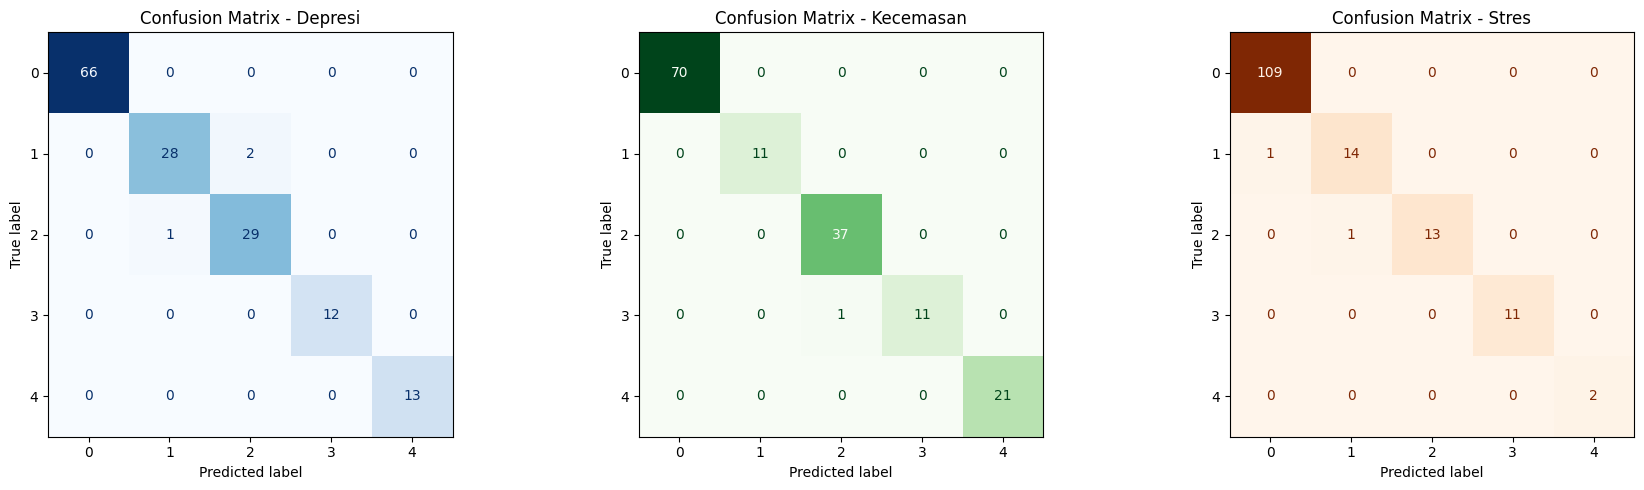

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\nMenghitung dan Menampilkan Confusion Matrix...")

# Prediksi menggunakan model yang sudah dilatih
y_pred_depresi = svm_depresi.predict(X_scaled)
y_pred_kecemasan = svm_anxiety.predict(X_scaled)
y_pred_stres = svm_stress.predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Depresi
cm_depresi = confusion_matrix(y_depresi, y_pred_depresi)
disp_depresi = ConfusionMatrixDisplay(confusion_matrix=cm_depresi)
disp_depresi.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Depresi')

# Kecemasan
cm_kecemasan = confusion_matrix(y_kecemasan, y_pred_kecemasan)
disp_kecemasan = ConfusionMatrixDisplay(confusion_matrix=cm_kecemasan)
disp_kecemasan.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Kecemasan')

# Stres
cm_stres = confusion_matrix(y_stres, y_pred_stres)
disp_stres = ConfusionMatrixDisplay(confusion_matrix=cm_stres)
disp_stres.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Confusion Matrix - Stres')

plt.tight_layout()
plt.show()


In [5]:
from sklearn.metrics import classification_report, accuracy_score

print("\n" + "="*50)
print("EVALUASI MODEL: DEPRESI")
print("="*50)
print(f"Accuracy: {accuracy_score(y_depresi, y_pred_depresi):.4f}")
print("\nClassification Report:")
print(classification_report(y_depresi, y_pred_depresi, zero_division=0))

print("\n" + "="*50)
print("EVALUASI MODEL: KECEMASAN")
print("="*50)
print(f"Accuracy: {accuracy_score(y_kecemasan, y_pred_kecemasan):.4f}")
print("\nClassification Report:")
print(classification_report(y_kecemasan, y_pred_kecemasan, zero_division=0))

print("\n" + "="*50)
print("EVALUASI MODEL: STRES")
print("="*50)
print(f"Accuracy: {accuracy_score(y_stres, y_pred_stres):.4f}")
print("\nClassification Report:")
print(classification_report(y_stres, y_pred_stres, zero_division=0))



EVALUASI MODEL: DEPRESI
Accuracy: 0.9801

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       0.97      0.93      0.95        30
           2       0.94      0.97      0.95        30
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        13

    accuracy                           0.98       151
   macro avg       0.98      0.98      0.98       151
weighted avg       0.98      0.98      0.98       151


EVALUASI MODEL: KECEMASAN
Accuracy: 0.9934

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        11
           2       0.97      1.00      0.99        37
           3       1.00      0.92      0.96        12
           4       1.00      1.00      1.00        21

    accuracy                           0.99       1